In [1]:
import os
import sklearn
import shutil
import random
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749',
    labels=None,
    shuffle=True,
    batch_size=32,

)

Found 104068 files.


# 1. EDA

In [3]:
dataset_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
valid_ext = ('.jpg', '.jpeg', '.png')

count_total = 0
count_valid = 0

for f in os.listdir(dataset_path):
    count_total += 1
    ext = os.path.splitext(f)[1].lower()
    if ext in valid_ext:
        count_valid += 1

print("Total files:", count_total)
print("Valid images:", count_valid)
print("Invalid files:", count_total - count_valid)

Total files: 104068
Valid images: 104068
Invalid files: 0


In [4]:
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
valid_ext = ('.jpg', '.jpeg', '.png')

ext_count = {}

for f in os.listdir(folder_path):
    ext = os.path.splitext(f)[1].lower()
    if ext in valid_ext:
        ext_count[ext] = ext_count.get(ext, 0) + 1

print("Image extension counts:")
for ext, count in ext_count.items():
    print(f"{ext}: {count}")

Image extension counts:
.jpg: 100119
.png: 3949


In [5]:
print("Total number of images", 100119+3949)

Total number of images 104068


In [6]:
#Check Image Dimensions and sizes (first 5 images only)
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
count = 0

for img_file in os.listdir(folder_path):
    path = os.path.join(folder_path, img_file)

    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        try:
            with Image.open(path) as img:
                width, height = img.size
                size_mb = os.path.getsize(path) / (1024 * 1024)

            print(f"{img_file}: {width}x{height} px, {size_mb:.2f} MB")
            count += 1

            if count == 5:
                break

        except Exception as e:
            print(f"Cannot open {img_file}: {e}")


1.jpg: 224x224 px, 0.01 MB
10.jpg: 224x224 px, 0.02 MB
100.jpg: 224x224 px, 0.01 MB
1000.jpg: 224x224 px, 0.01 MB
10000.jpg: 224x224 px, 0.01 MB


In [31]:
# Check the number of corrupted imageswith out deletind them
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
corrupted_images = []

for img_file in os.listdir(folder_path):
    path = os.path.join(folder_path, img_file)
    if img_file.endswith(('.jpg', '.png', '.jpeg')):
        try:
            with Image.open(path) as img:  # safely open image
                img.verify()  # check if image is readable
        except (OSError, IOError):
            corrupted_images.append(img_file)  # add corrupted image to list

print(f"Total corrupted images: {len(corrupted_images)}")
print("List of corrupted images:")
for img in corrupted_images:
    print(img)


Total corrupted images: 0
List of corrupted images:


In [9]:
# 1.Remove corrupted images
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
corrupted_count = 0

for img_file in os.listdir(folder_path):
    path = os.path.join(folder_path, img_file)
    
    # Only check image files
    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        try:
            with Image.open(path) as img:  # safely open image
                img.verify()  # check if image is corrupted
        except (OSError, IOError):
            corrupted_count += 1
            try:
                os.remove(path)  # remove corrupted image
                print(f"Removed corrupted image: {img_file}")
            except PermissionError:
                print(f"Cannot delete {img_file}, file is in use.")

print(f"\nTotal corrupted images removed: {corrupted_count}")


Total corrupted images removed: 0


In [10]:
# 2.Resize images
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
new_size = (224, 224)
removed = 0
for img_file in os.listdir(folder_path):
    path = os.path.join(folder_path, img_file)
    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        try:
            # First check corruption
            with Image.open(path) as img:
                img.verify()
            # Reopen for resizing
            with Image.open(path) as img:
                img = img.resize(new_size)
                img.save(path)
        except Exception as e:
            print(f"Removing corrupted image: {img_file}")
            try:
                os.remove(path)
                removed += 1
            except:
                pass
print(f"\nTotal corrupted images removed: {removed}")
print("All valid images resized successfully!")


Total corrupted images removed: 0
All valid images resized successfully!


In [11]:
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
expected_size = (224, 224)
correct = 0
incorrect = 0
for img_file in os.listdir(folder_path):
    path = os.path.join(folder_path, img_file)
    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        try:
            with Image.open(path) as img:
                if img.size == expected_size:
                    correct += 1
                else:
                    incorrect += 1
                    print(f"Not resized: {img_file} -> {img.size}")
        except:
            print(f"Corrupted image: {img_file}")
print("\nResize Check Summary")
print(f"Correctly resized images: {correct}")
print(f"Not resized images: {incorrect}")


Resize Check Summary
Correctly resized images: 104068
Not resized images: 0


Image shape: (224, 224, 3)


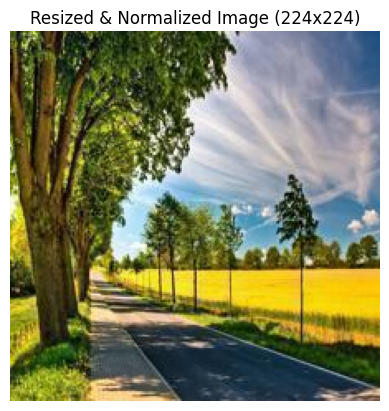

In [7]:
image_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749\1.jpg"

# Open, resize, normalize
img = Image.open(image_path).convert("RGB").resize((224, 224))
img_array = np.array(img, dtype=np.float32) / 255.0

# Print shape
print("Image shape:", img_array.shape)

# Show image
plt.imshow(img_array)
plt.axis("off")
plt.title("Resized & Normalized Image (224x224)")
plt.show()

In [13]:
# 3 normalizeath to dataset images
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
# Parameters
batch_size = 9000
image_size = (224, 224)

# Get all image files
image_files = [
    f for f in os.listdir(folder_path)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
]

total_images = len(image_files)
print(f"Total images in dataset: {total_images}")

# Process in batches
for start in range(0, total_images, batch_size):
    end = min(start + batch_size, total_images)
    batch_files = image_files[start:end]

    batch_images = []

    for img_file in batch_files:
        path = os.path.join(folder_path, img_file)
        try:
            img = Image.open(path).convert("RGB")
            img = img.resize(image_size)

            img_array = np.array(img, dtype=np.float32) / 255.0  # normalize
            batch_images.append(img_array)

        except Exception as e:
            print(f"Skipped {img_file}: {e}")

    batch_images = np.array(batch_images, dtype=np.float32)

    print(
        f"Processed images {start + 1} to {end} "
        f"out of {total_images}"
    )

    # Clear RAM explicitly
    del batch_images

print("✅ Normalization completed for entire dataset!")

Total images in dataset: 104068
Processed images 1 to 9000 out of 104068
Processed images 9001 to 18000 out of 104068
Processed images 18001 to 27000 out of 104068
Processed images 27001 to 36000 out of 104068
Processed images 36001 to 45000 out of 104068
Processed images 45001 to 54000 out of 104068
Processed images 54001 to 63000 out of 104068
Processed images 63001 to 72000 out of 104068
Processed images 72001 to 81000 out of 104068
Processed images 81001 to 90000 out of 104068
Processed images 90001 to 99000 out of 104068
Processed images 99001 to 104068 out of 104068
✅ Normalization completed for entire dataset!


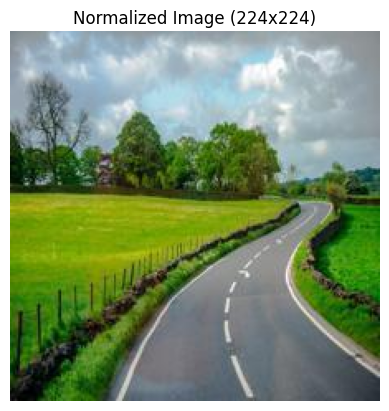

Shape: (224, 224, 3)
Min: 0.0 Max: 1.0

Sample pixel values (Top-left pixel):
Before normalization (0–255): [122 133 139]
After normalization (0–1): [0.47843137 0.52156866 0.54509807]


In [6]:
img_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749\53.jpg"

# Load image
img = Image.open(img_path).convert("RGB")
img = img.resize((224, 224))

# Convert to array (before normalization)
img_array_raw = np.array(img)

# Normalize
img_array = img_array_raw.astype(np.float32) / 255.0

# Show image
plt.imshow(img_array)
plt.axis("off")
plt.title("Normalized Image (224x224)")
plt.show()

# Verify normalization
print("Shape:", img_array.shape)
print("Min:", img_array.min(), "Max:", img_array.max())

# Show sample pixel values
print("\nSample pixel values (Top-left pixel):")
print("Before normalization (0–255):", img_array_raw[0, 0])
print("After normalization (0–1):", img_array[0, 0])

In [15]:
# 4.Remove Duplicates
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
hashes = {}
removed = 0

for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        path = os.path.join(folder_path, img_file)
        try:
            with Image.open(path) as img:
                img_hash = imagehash.phash(img)

            if img_hash in hashes:
                # Duplicate found → remove
                os.remove(path)
                removed += 1
                print(f"Removed duplicate: {img_file}")
            else:
                hashes[img_hash] = img_file

        except Exception as e:
            print(f"Skipped {img_file}: {e}")

print(f"\n✅ Total duplicate images removed: {removed}")
print(f"✅ Unique images remaining: {len(hashes)}")



✅ Total duplicate images removed: 0
✅ Unique images remaining: 104068


In [16]:
# 4.Remove Duplicates
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
# Count total images BEFORE
total_before = len([
    f for f in os.listdir(folder_path)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])

hashes = {}
removed = 0

for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        path = os.path.join(folder_path, img_file)
        try:
            with Image.open(path) as img:
                img_hash = imagehash.phash(img)

            if img_hash in hashes:
                os.remove(path)
                removed += 1
            else:
                hashes[img_hash] = img_file

        except Exception as e:
            print(f"Skipped {img_file}: {e}")

# Count total images AFTER
total_after = total_before - removed

print(f"📌 Total images before: {total_before}")
print(f"🗑️ Duplicate images removed: {removed}")
print(f"✅ Total images after: {total_after}")


📌 Total images before: 104068
🗑️ Duplicate images removed: 0
✅ Total images after: 104068


In [17]:
# Scan dataset (count everythinng of images)
folder_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
hashes = {}
total_images = 0
corrupted_images = 0
duplicate_images = 0

# Loop through dataset
for img_file in os.listdir(folder_path):
    if img_file.lower().endswith(('.jpg', '.png', '.jpeg')):
        total_images += 1
        path = os.path.join(folder_path, img_file)

        try:
            # Check corrupted image
            with Image.open(path) as img:
                img.verify()

            # Reopen for hashing
            with Image.open(path) as img:
                img = img.convert("RGB")
                img_hash = imagehash.phash(img)

            # Check duplicate
            if img_hash in hashes:
                duplicate_images += 1
            else:
                hashes[img_hash] = img_file

        except Exception:
            corrupted_images += 1

# Calculate valid images
valid_images = total_images - corrupted_images - duplicate_images

# Print summary
print("📊 DATASET SUMMARY")
print(f"Total images      : {total_images}")
print(f"Corrupted images  : {corrupted_images}")
print(f"Duplicate images  : {duplicate_images}")
print(f"Valid images      : {valid_images}")

📊 DATASET SUMMARY
Total images      : 104068
Corrupted images  : 0
Duplicate images  : 0
Valid images      : 104068


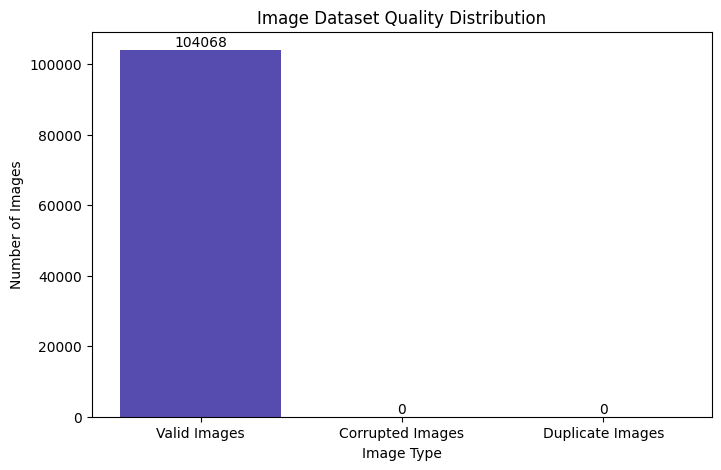

In [18]:
# Data
labels = ['Valid Images', 'Corrupted Images', 'Duplicate Images']
sizes = [valid_images, corrupted_images, duplicate_images]
colors = ["#564CAF"]  

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, sizes, color=colors)
plt.title("Image Dataset Quality Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Image Type")

# Add numbers on top of bars
for i, size in enumerate(sizes):
    plt.text(i, size + 50, str(size), ha='center', va='bottom', fontsize=10)

plt.show()

# 2.EDA CSV Dataset

In [7]:
csv_path = r"C:\Users\ASH\Downloads\download_log_megabatch_200k.csv"
df = pd.read_csv(csv_path)


In [8]:
df.head()

,id,filename,keyword_source,original_url,extension,label,label_encoded
0,1,1.jpg,country road,https://wallpapers.com/images/hd/country-road-...,jpg,SAFE,0
1,2,2.jpg,country road,https://wallpapers.com/images/hd/country-road-...,jpg,SAFE,0
2,3,3.jpg,country road,https://wallpapercave.com/wp/wp2364206.jpg,jpg,SAFE,0
3,4,4.jpg,country road,https://st.depositphotos.com/1669366/1389/i/95...,jpg,SAFE,0
4,5,5.jpg,country road,https://images.freeimages.com/images/large-pre...,jpg,SAFE,0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102381 entries, 0 to 102380
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id              102381 non-null  int64 
 1   filename        102381 non-null  object
 2   keyword_source  102381 non-null  object
 3   original_url    102381 non-null  object
 4   extension       102381 non-null  object
 5   label           102381 non-null  object
 6   label_encoded   102381 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 5.5+ MB


In [33]:
df.columns

Index(['id', 'filename', 'keyword_source', 'original_url', 'extension',
       'label', 'label_encoded'],
      dtype='object')

In [34]:
df.isnull().sum()


id                0
filename          0
keyword_source    0
original_url      0
extension         0
label             0
label_encoded     0
dtype: int64

In [35]:
df["label"].value_counts()


label
SAFE    82022
NSFW    20359
Name: count, dtype: int64

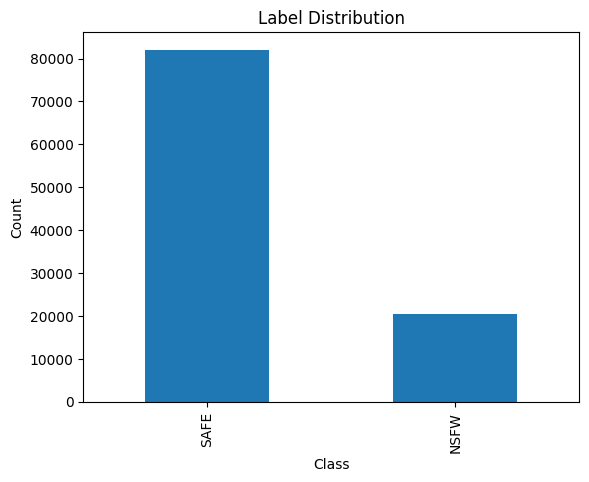

In [36]:
df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


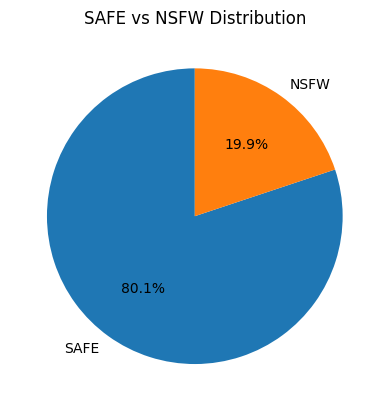

In [37]:
df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("SAFE vs NSFW Distribution")
plt.ylabel("")
plt.show()


In [29]:
df["keyword_source"].nunique()



1849

In [38]:
df["keyword_length"] = df["keyword_source"].str.split().apply(len)

df["keyword_length"].describe()


count    102381.000000
mean          2.548871
std           1.199624
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           7.000000
Name: keyword_length, dtype: float64

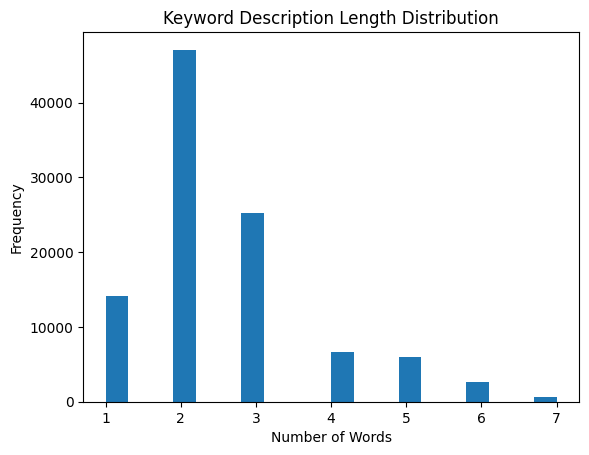

In [39]:
df["keyword_length"].plot(kind="hist", bins=20)
plt.title("Keyword Description Length Distribution")
plt.xlabel("Number of Words")
plt.show()


In [40]:
# Most common keywords
from collections import Counter

words = " ".join(df["keyword_source"].dropna()).lower().split()
common_words = Counter(words).most_common(10)

common_words


[('nude', 10518),
 ('art', 4855),
 ('girl', 2576),
 ('erotic', 2013),
 ('of', 1474),
 ('sensual', 1425),
 ('in', 1401),
 ('city', 1128),
 ('naked', 1073),
 ('body', 1049)]

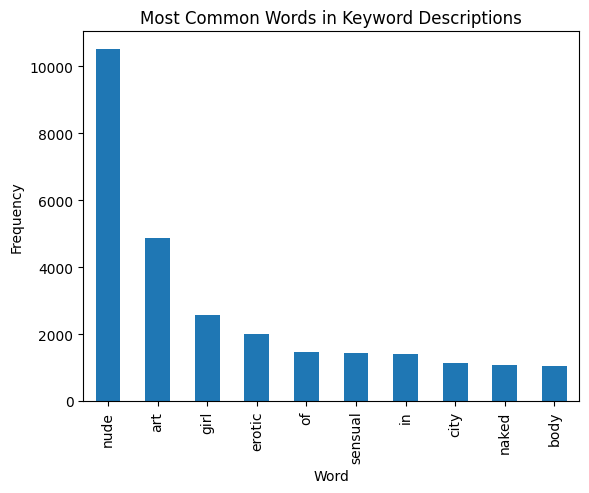

In [41]:
words_df = pd.DataFrame(common_words, columns=["word", "count"])
words_df.plot(x="word", y="count", kind="bar", legend=False)
plt.title("Most Common Words in Keyword Descriptions")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.show()


In [42]:
df["keyword_source"].sample(5)


21083                                  surfer
5556     buddhist monks praying temple serene
86882                               dragonfly
96292                            snow leopard
34599                               smoke art
Name: keyword_source, dtype: object

In [43]:
from collections import Counter

all_words = (
    df["keyword_source"]
    .dropna()
    .str.lower()
    .str.split()
    .explode()
)

unique_words = all_words.unique()

print(f"Total unique words: {(unique_words)}")


Total unique words: ['country' 'road' 'erotic' ... 'utah' 'macaw' 'flight']


In [44]:
nsfw_keywords = [
    "nude", "nudity", "naked",
    "sex", "sexual", "porn", "porno",
    "erotic", "erotica",
    "xxx", "18+",
    "boobs", "breasts", "ass", "pussy",
    "penis", "vagina",
    "lingerie", "bikini", "underwear",
    "strip", "striptease", "lap dance",
    "masturbation", "orgasm",
    "fetish", "bondage",
    "nsfw", "explicit",
    "thong", "panty", "see-through",
    "camgirl", "webcam",
    "sex toy", "hardcore", "softcore"
]


In [45]:
def map_to_safe_nsfw(label):
    label = str(label).lower()
    for word in nsfw_keywords:
        if word in label:
            return "NSFW"
    return "SAFE"

df["label"] = df["keyword_source"].apply(map_to_safe_nsfw)


In [46]:
df["label_encoded"] = df["label"].map({
    "SAFE": 0,
    "NSFW": 1
})


In [47]:
df["label"].value_counts()


label
SAFE    82022
NSFW    20359
Name: count, dtype: int64

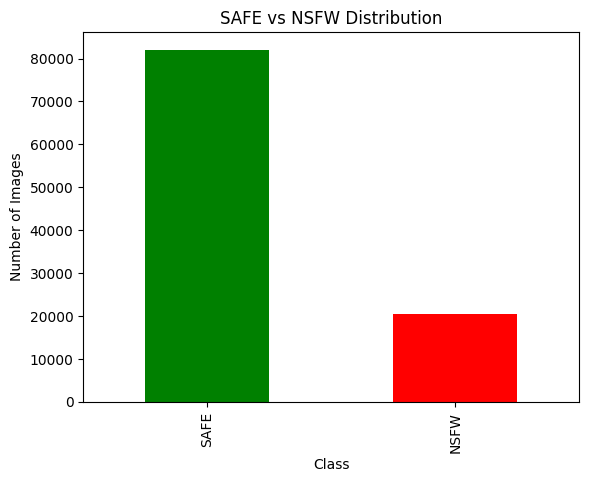

In [48]:
df["label"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("SAFE vs NSFW Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


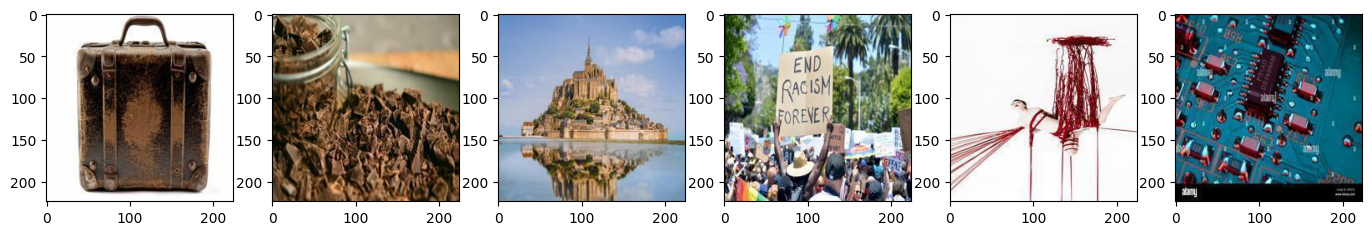

In [29]:
IMAGE_DIR = r"C:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"
IMAGE_COL = "filename"  # <-- use the actual column name for image filenames

# SAFE images
safe_imgs = df[df["label"] == "SAFE"][IMAGE_COL].astype(str)
safe_imgs = [f for f in safe_imgs if os.path.exists(os.path.join(IMAGE_DIR, f))]

# pick 6 random
selected = random.sample(safe_imgs, 6)

plt.figure(figsize=(17,17))
for i, img_name in enumerate(selected):
    img_path = os.path.join(IMAGE_DIR, img_name)
    img = Image.open(img_path).convert("RGB")
    plt.subplot(6,6,i+1)
    plt.imshow(img)

plt.show()


In [30]:
CSV_PATH = r"C:\Users\ASH\Downloads\download_log_megabatch_200k.csv"
IMAGE_DIR = r"C:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749"

# 2️⃣ Load CSV

df = pd.read_csv(CSV_PATH)

# Replace this with the column that contains your image filenames
IMAGE_COL = "filename"  # <-- change if different in your CSV

# 3️⃣ Map SAFE/NSFW labels
nsfw_keywords = ["nude", "porn", "sex", "erotic", "boobs", "pussy", "naked"]  # add more if needed

def map_to_safe_nsfw(label):
    label = str(label).lower()
    for word in nsfw_keywords:
        if word in label:
            return "NSFW"
    return "SAFE"

# Create label column if not exists
if "label" not in df.columns:
    df["label"] = df["keyword_source"].apply(map_to_safe_nsfw)

# Encode labels: SAFE=0, NSFW=1
df["label_encoded"] = df["label"].map({"SAFE":0, "NSFW":1})


# 4️⃣ Keep only existing images

df = df[df[IMAGE_COL].apply(lambda x: os.path.exists(os.path.join(IMAGE_DIR, str(x))))]


# 5️⃣ Split dataset
train_df, test_df = train_test_split(
    df, 
    test_size=0.2,         # 20% for testing
    stratify=df["label_encoded"],  # keeps proportion of SAFE/NSFW
    random_state=42
)

print("Total images:", len(df))
print("Train images:", len(train_df))
print("Test images:", len(test_df))


# 6️⃣ Optional: Check distribution
print("Train label counts:\n", train_df["label"].value_counts())
print("Test label counts:\n", test_df["label"].value_counts())


Total images: 102381
Train images: 81904
Test images: 20477
Train label counts:
 label
SAFE    65617
NSFW    16287
Name: count, dtype: int64
Test label counts:
 label
SAFE    16405
NSFW     4072
Name: count, dtype: int64


Total images: 102381
SAFE images: 82022
NSFW images: 20359


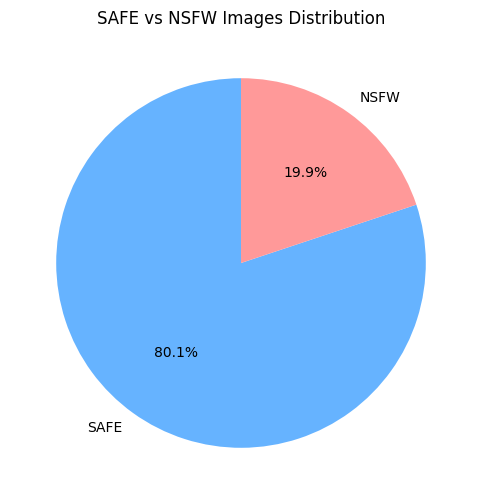

In [31]:
# Separate SAFE and NSFW images
# -----------------------------
safe_images = df[df["label"] == "SAFE"]
nsfw_images = df[df["label"] == "NSFW"]

# Print totals
print("Total images:", len(df))
print("SAFE images:", len(safe_images))
print("NSFW images:", len(nsfw_images))

# Pie chart of SAFE vs NSFW
# -----------------------------
counts = [len(safe_images), len(nsfw_images)]
labels = ["SAFE", "NSFW"]
colors = ["#66b3ff", "#ff9999"]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
plt.title("SAFE vs NSFW Images Distribution")
plt.show()


# : Feature Extraction Model

In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained backbone
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers (feature extraction)
base_model.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

# Model
model = Model(inputs=base_model.input, outputs=output)

# Compile (higher LR is OK when frozen)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#model.summary()


In [33]:
print("Base model trainable:", base_model.trainable)

print("\nFirst 5 base layers:")
for layer in base_model.layers[:5]:
    print(layer.name, layer.trainable)

print("\nLast 5 model layers:")
for layer in model.layers[-5:]:
    print(layer.name, layer.trainable)

print("\nLearning rate:", model.optimizer.learning_rate.numpy())



Base model trainable: False

First 5 base layers:
input_layer False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False

Last 5 model layers:
out_relu False
global_average_pooling2d True
dense True
dropout True
dense_1 True

Learning rate: 1e-04


In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 81904 validated image filenames belonging to 2 classes.
Found 20477 validated image filenames belonging to 2 classes.


In [35]:
history = model.fit(
    train_generator,
    epochs=3,                 # feature extraction phase
    validation_data=test_generator
)


Epoch 1/3
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 3925s 2s/step - accuracy: 0.9155 - loss: 0.2318 - val_accuracy: 0.9232 - val_loss: 0.2045
Epoch 2/3
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 3513s 1s/step - accuracy: 0.9250 - loss: 0.2038 - val_accuracy: 0.9269 - val_loss: 0.1960
Epoch 3/3
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 2538s 991ms/step - accuracy: 0.9273 - loss: 0.1937 - val_accuracy: 0.9286 - val_loss: 0.1900


In [36]:
# Evaluate model on test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


640/640 ━━━━━━━━━━━━━━━━━━━━ 608s 950ms/step - accuracy: 0.9286 - loss: 0.1900
Test Loss: 0.1900
Test Accuracy: 0.9286


In [37]:
# Predict probabilities
y_pred_prob = model.predict(test_generator)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = test_generator.classes


640/640 ━━━━━━━━━━━━━━━━━━━━ 449s 698ms/step


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report (precision, recall, F1-score)
target_names = list(test_generator.class_indices.keys())  # ['SAFE', 'NSFW']
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))


Confusion Matrix:
 [[ 3264   808]
 [  654 15751]]

Classification Report:

              precision    recall  f1-score   support

        NSFW       0.83      0.80      0.82      4072
        SAFE       0.95      0.96      0.96     16405

    accuracy                           0.93     20477
   macro avg       0.89      0.88      0.89     20477
weighted avg       0.93      0.93      0.93     20477



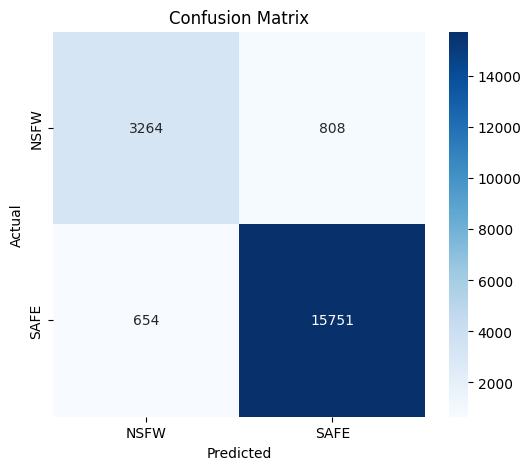

In [39]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


640/640 ━━━━━━━━━━━━━━━━━━━━ 511s 797ms/step


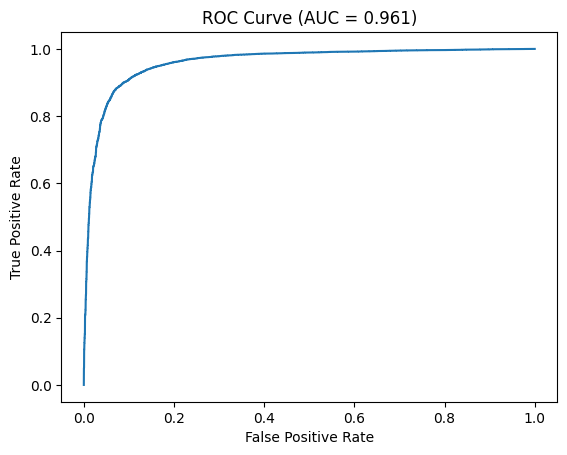

AUC Score: 0.9606875614136042


In [41]:
# 1️⃣ ROC Curve + AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_scores = model.predict(test_generator).ravel()

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()

print("AUC Score:", roc_auc)


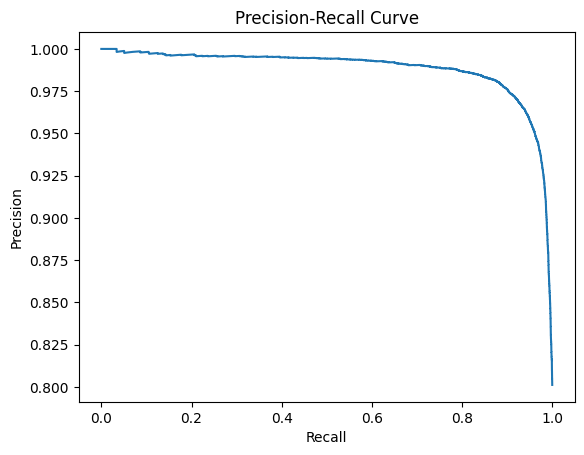

In [42]:
# 2️⃣ Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


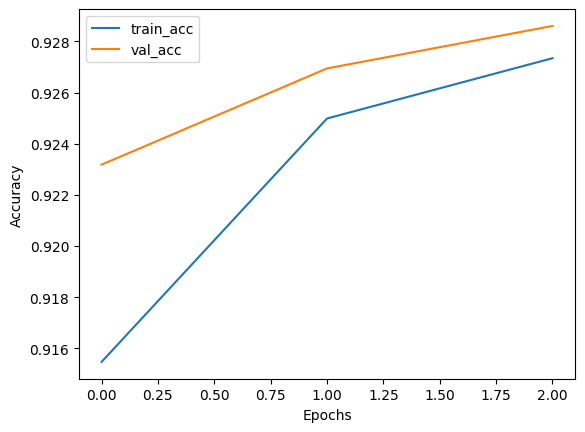

In [40]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


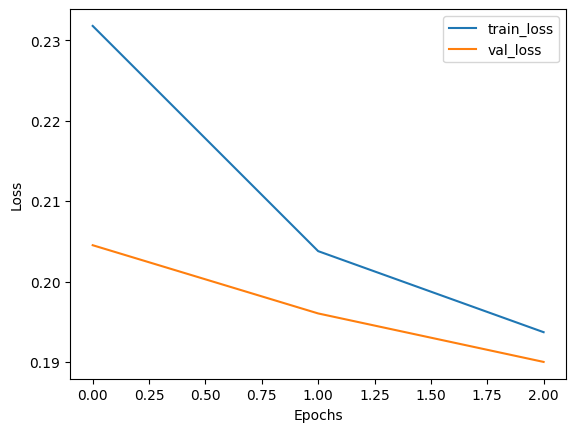

In [43]:
# plot loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Fine-Tuning Model

In [44]:
# Unfreeze top N layers for fine-tuning
FINE_TUNE_AT = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True


In [45]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 🔻 lower LR
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#model.summary()


In [46]:

# Fine-Tuning Verification Script

print("Base model trainable:", base_model.trainable)

print("\nFirst 5 base layers (should still be frozen):")
for layer in base_model.layers[:5]:
    print(layer.name, layer.trainable)

print("\nTop 10 base layers (should be unfrozen for fine-tuning):")
for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

print("\nHead layers (classification layers, must be trainable):")
for layer in model.layers[-5:]:
    print(layer.name, layer.trainable)

print("\nTotal params, Trainable params, Non-trainable params:")


print("\nCurrent learning rate:", model.optimizer.learning_rate.numpy())


Base model trainable: False

First 5 base layers (should still be frozen):
input_layer False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False

Top 10 base layers (should be unfrozen for fine-tuning):
block_16_expand_BN True
block_16_expand_relu True
block_16_depthwise True
block_16_depthwise_BN True
block_16_depthwise_relu True
block_16_project True
block_16_project_BN True
Conv_1 True
Conv_1_bn True
out_relu True

Head layers (classification layers, must be trainable):
out_relu True
global_average_pooling2d True
dense True
dropout True
dense_1 True

Total params, Trainable params, Non-trainable params:

Current learning rate: 1e-05


In [47]:
history_finetune = model.fit(
    train_generator,
    epochs=4,                # fine-tuning phase
    validation_data=test_generator
)


Epoch 1/4
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 5215s 2s/step - accuracy: 0.9254 - loss: 0.2009 - val_accuracy: 0.9325 - val_loss: 0.1839
Epoch 2/4
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 5173s 2s/step - accuracy: 0.9321 - loss: 0.1790 - val_accuracy: 0.9335 - val_loss: 0.1799
Epoch 3/4
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 4492s 2s/step - accuracy: 0.9365 - loss: 0.1661 - val_accuracy: 0.9349 - val_loss: 0.1780
Epoch 4/4
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 4795s 2s/step - accuracy: 0.9389 - loss: 0.1582 - val_accuracy: 0.9358 - val_loss: 0.1724


In [48]:
# Evaluate model on test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


640/640 ━━━━━━━━━━━━━━━━━━━━ 437s 682ms/step - accuracy: 0.9358 - loss: 0.1724
Test Loss: 0.1724
Test Accuracy: 0.9358


In [49]:
# Predict probabilities
y_pred_prob = model.predict(test_generator)

# Convert probabilities to class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = test_generator.classes


640/640 ━━━━━━━━━━━━━━━━━━━━ 557s 863ms/step


In [50]:
from sklearn.metrics import classification_report, confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report (precision, recall, F1-score)
target_names = list(test_generator.class_indices.keys())  # ['SAFE', 'NSFW']
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))


Confusion Matrix:
 [[ 3294   778]
 [  537 15868]]

Classification Report:

              precision    recall  f1-score   support

        NSFW       0.86      0.81      0.83      4072
        SAFE       0.95      0.97      0.96     16405

    accuracy                           0.94     20477
   macro avg       0.91      0.89      0.90     20477
weighted avg       0.93      0.94      0.94     20477



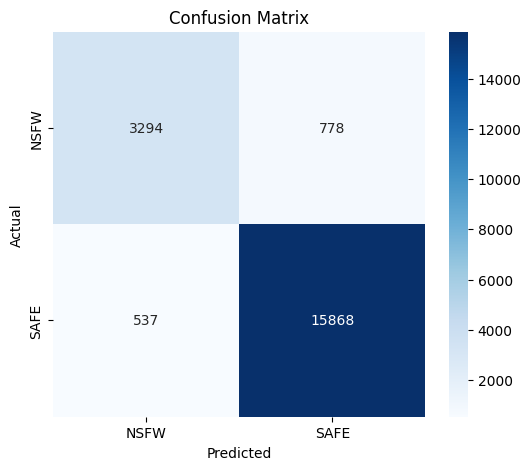

In [51]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


640/640 ━━━━━━━━━━━━━━━━━━━━ 568s 887ms/step


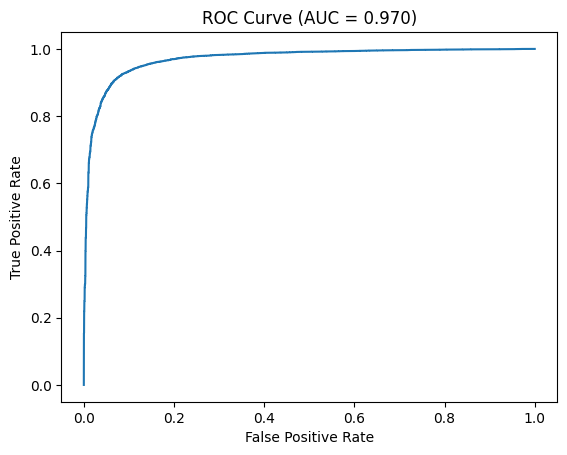

AUC Score: 0.9704902953781042


In [52]:
# 1️⃣ ROC Curve + AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_scores = model.predict(test_generator).ravel()

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()

print("AUC Score:", roc_auc)

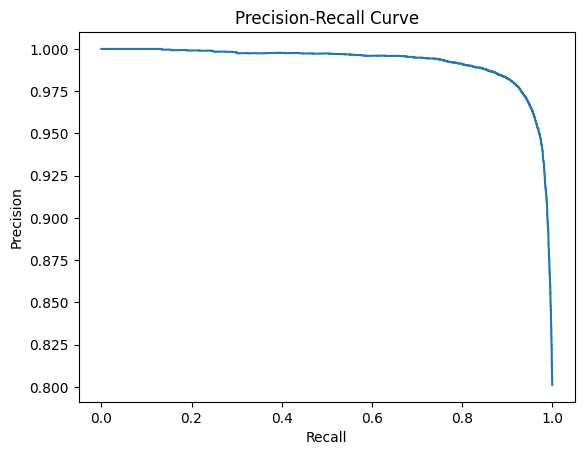

In [53]:
# 2️⃣ Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

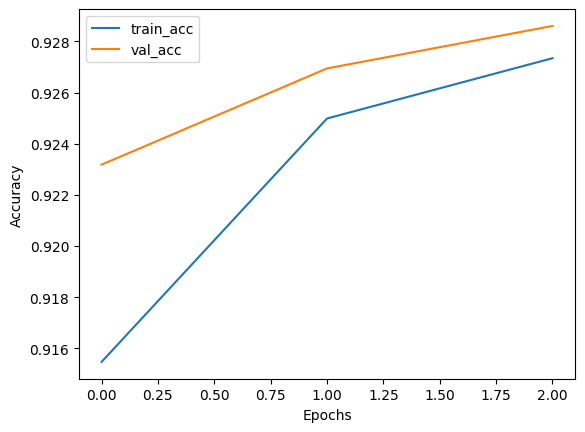

In [54]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


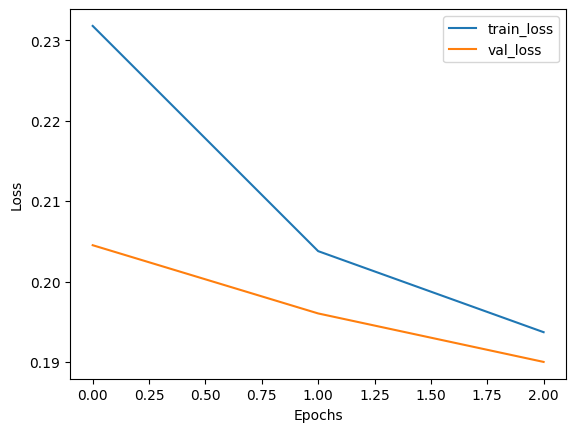

In [55]:
# plot loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# save model
model.save("nsfw_classifier_mobilenetv2.h5")


In [ ]:
#predictionon single images
img_path = r"c:\Users\ASH\Downloads\archive (8)\MegaBatch_200k_Images_105749\53.jpg"
